In [1]:
import os
import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# use all available GPUs on the machine
gpus_to_use = range(torch.cuda.device_count())
# # use only a single GPU
# gpus_to_use = [torch.cuda.current_device()]

from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

/cluster/scratch/niacobone/sam3/myenv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-06-07 12:00:01,931 2717719 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-06-07 12:00:02,188 2717719 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-06-07 12:00:02,189 2717719 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-06-07 12:00:07,097 2717719 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-06-07 12:00:10,385 2717719 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-06-07 12:00:10,386 2717719 sam3_video_predictor.py: 140: 


	*** DONE loading model on all

In [2]:
CLASSES = [
    "wall",
    "floor",
    "cabinet",
    "bed",
    "chair",
    "sofa",
    "table",
    "door",
    "window",
    "bookshelf",
    "picture",
    "counter",
    "desk",
    "curtain",
    "refrigerator",
    "shower curtain",
    "toilet",
    "sink",
    "bathtub",
]

In [4]:
import os
import shutil
import tempfile

from tqdm import tqdm

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

scene_path = '/cluster/work/igp_psr/niacobone/distillation/dataset/scannet/scans/scene0000_00/raw_data/color'

# Build indices: 0, 4, 9, 14, ... and keep at most 100 frames in total.
target_indices = [0] + [4 + 5 * i for i in range(99)]

# Keep only existing files (0.jpg, 1.jpg, ... naming).
selected_frame_names = [
    f"{idx}.jpg" for idx in target_indices if os.path.exists(os.path.join(scene_path, f"{idx}.jpg"))
]

if not selected_frame_names:
    raise RuntimeError(f"No sampled frames found in {scene_path}")

# Create a temporary folder containing only sampled frames for this session.
sampled_frames_dir = tempfile.mkdtemp(prefix='sam3_sampled_frames_')
for frame_name in selected_frame_names:
    src = os.path.join(scene_path, frame_name)
    dst = os.path.join(sampled_frames_dir, frame_name)
    try:
        os.symlink(src, dst)
    except OSError:
        # Fallback if symlinks are not available on the current filesystem.
        shutil.copy2(src, dst)

response = predictor.handle_request(
    request=dict(
        type='start_session',
        resource_path=sampled_frames_dir,
    )
)
session_id = response['session_id']

_ = predictor.handle_request(
    request=dict(
        type='reset_session',
        session_id=session_id,
    )
)

frame_idx = 0
outputs_per_class = {}

for class_name in tqdm(CLASSES, desc='class name prompt'):
    prompt_text_str = class_name
    response = predictor.handle_request(
        request=dict(
            type='add_prompt',
            session_id=session_id,
            frame_index=frame_idx,
            text=prompt_text_str,
        )
    )

    out = response['outputs']
    if len(out['out_boxes_xywh']) != 0:
        print(f"Find {prompt_text_str} object")

    outputs_per_frame = propagate_in_video(predictor, session_id)
    outputs_per_class[prompt_text_str] = outputs_per_frame
    print(f"Tracked {prompt_text_str}: {len(outputs_per_frame)} frames")

print(outputs_per_class)

_ = predictor.handle_request(
    request=dict(
        type='close_session',
        session_id=session_id,
    )
)

# Optional cleanup of the temporary sampled directory.
shutil.rmtree(sampled_frames_dir, ignore_errors=True)

INFO 2026-06-07 12:01:41,961 2717719 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-06-07 12:01:41,963 2717719 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-06-07 12:01:41,963 2717719 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-06-07 12:01:46,176 2717719 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-06-07 12:01:47,736 2717719 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-06-07 12:01:47,737 2717719 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 100/100 [00:04<00:00, 24.10it/s]
INFO 2026-06-07 12:01:54,679 2717719 sam3_base_predictor.py: 153: started new session 89fbbb2f-b294-4a77-8854-743fd6bf7fa3
class name prompt:   0%|          | 0/19 [00:00<?, ?it/s]

Find wall object


propagate_in_video:   0%|          | 0/100 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-06-07 12:02:16,221 2717719 sam3_base_predictor.py: 311: propagation ended in session 89fbbb2f-b294-4a77-8854-743fd6bf7fa3
class name prompt:   5%|▌         | 1/19 [00:21<06:27, 21.54s/it]

...

propagate_in_video:   0%|          | 0/100 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-06-07 12:05:07,176 2717719 sam3_base_predictor.py: 311: propagation ended in session 89fbbb2f-b294-4a77-8854-743fd6bf7fa3
class name prompt: 100%|██████████| 19/19 [03:12<00:00, 10.13s/it]


Tracked bathtub: 100 frames
{'wall': {0: {'out_obj_ids': array([0, 1]), 'out_probs': array([0.8672199, 0.8632479], dtype=float32), 'out_boxes_xywh': array([[0.00694444, 0.12809917, 0.2685185 , 0.18491735],
       [0.61959875, 0.00826446, 0.18055555, 0.4721074 ]], dtype=float32), 'out_binary_masks': array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

INFO 2026-06-07 12:05:07,610 2717719 sam3_base_predictor.py: 414: removed session 89fbbb2f-b294-4a77-8854-743fd6bf7fa3


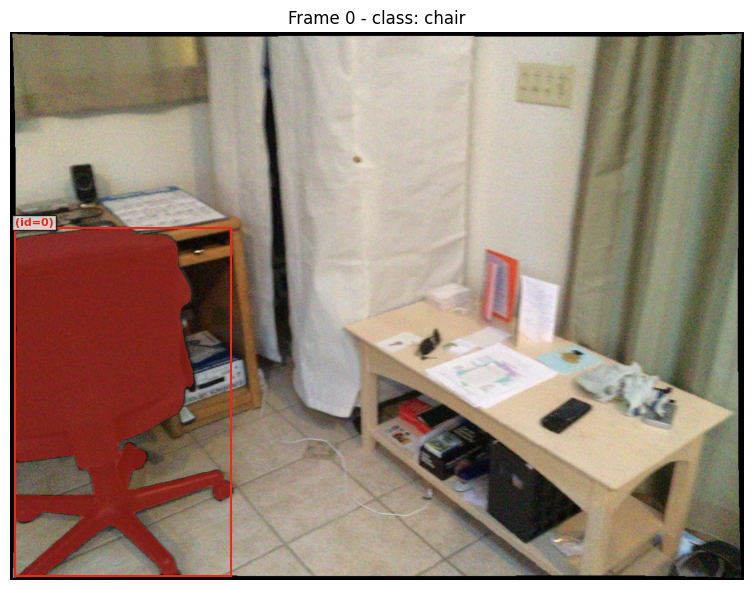

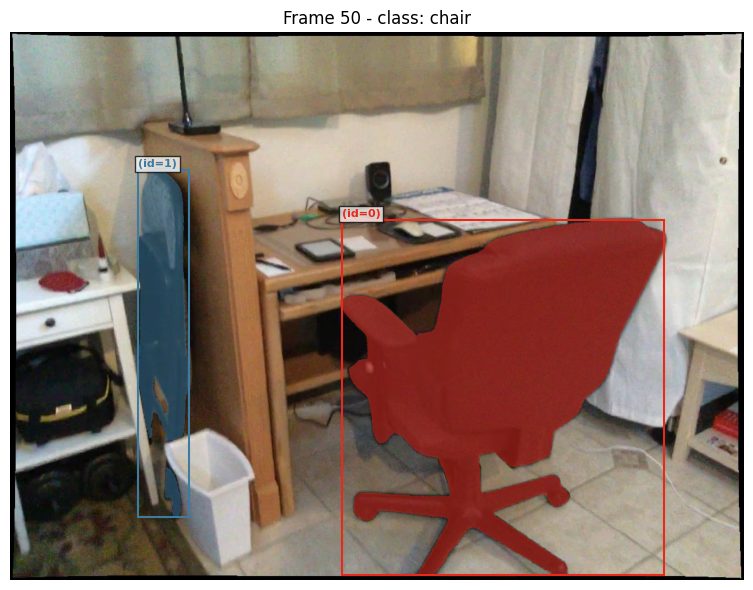

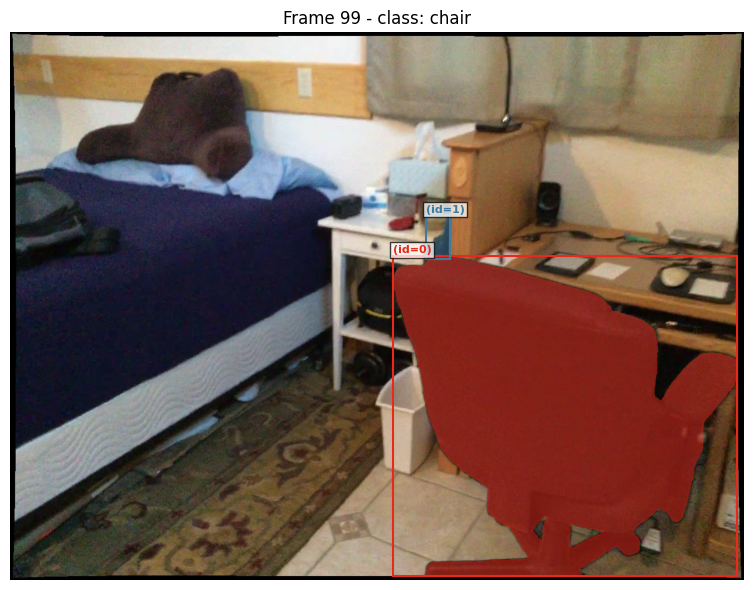

In [ ]:
from copy import deepcopy

# Build frame list in the same sampled order used for inference.
video_frames = [os.path.join(scene_path, name) for name in selected_frame_names]

for class_to_visualize in CLASSES:
    # Pick a class to visualize (change this string if needed).
    # class_to_visualize = 'chair'
    if class_to_visualize not in outputs_per_class:
        raise KeyError(f"{class_to_visualize=} not found in outputs_per_class")

    # Convert raw predictor outputs to {frame_idx: {obj_id: binary_mask}} format.
    frame_to_obj_masks = prepare_masks_for_visualization(
        deepcopy(outputs_per_class[class_to_visualize])
    )

    # Visualize a few frames (first, middle, last among available predicted frames).
    available_frames = sorted(frame_to_obj_masks.keys())
    if not available_frames:
        raise RuntimeError(f"No predicted masks available for class '{class_to_visualize}'")

    candidate_frames = [
        available_frames[0],
        available_frames[len(available_frames) // 2],
        available_frames[-1],
    ]

    # Keep order and remove duplicates.
    frames_to_show = list(dict.fromkeys(candidate_frames))

    for fidx in frames_to_show:
        visualize_formatted_frame_output(
            frame_idx=fidx,
            video_frames=video_frames,
            outputs_list=[frame_to_obj_masks],
            titles=[f"class: {class_to_visualize}"],
            figsize=(8, 6),
        )